# Avaliação da aorta em bancos CCTA externos

Esta análise compara as avaliações visuais e os alertas automáticos da aorta em resoluções mid e high no MM-WHS e no OrCaScore. Os percentuais incluem os exames “Não avaliável” ou “Sem feedback” no denominador. As classificações não são uma validação clínica.

O Dice do MM-WHS usa comparação direta nos 20 exames de treino e o avaliador oficial com label 820 nos exames de teste. Os protocolos são apresentados separadamente.

Os resultados quantitativos vêm dos runs de 06/10/2026: mid `2026-10-06_07-53-03` e high `2026-10-06_08-33-19`. As avaliações visuais foram copiadas, sem alteração, dos respectivos runs de 22/09/2026: mid `2026-09-22_18-51-28` e high `2026-09-22_17-47-45`. São avaliações históricas reutilizadas, não uma nova inspeção dos runs atuais.

In [1]:
# ruff: noqa: E402
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file()
)
sys.path.insert(0, str(REPO_ROOT / "src"))

from utils.project.analysis.external_aorta_assessment import (
    AORTA_FEEDBACK_ORDER,
    attach_aorta_feedback,
)
from utils.project.results.external import (
    load_mmwhs_train_aorta_dice,
    load_mmwhs_test_aorta_dice,
)
from utils.project.analysis.external_visual_assessment import (
    AORTA_ARTERY_STATUS_ORDER,
    attach_assessment_subsets,
    load_assessment_subset_lookup,
    load_external_visual_assessments,
    summarize_visual_status,
)

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

## Configuração e carregamento

In [2]:
EXTERNAL_RESULTS_ROOT = Path(
    os.environ.get(
        "EXTERNAL_CCTA_RESULTS_ROOT",
        "/run/media/matheus/HD/Results_dataset_ccta",
    )
)
RUN_DIRS = {
    "mid": {
        "MM-WHS": EXTERNAL_RESULTS_ROOT / "mmwhs/mid_res/2026-10-06_07-53-03",
        "OrCaScore": EXTERNAL_RESULTS_ROOT / "orcascore/mid_res/2026-09-19_10-23-50",
    },
    "high": {
        "MM-WHS": EXTERNAL_RESULTS_ROOT / "mmwhs/high_res/2026-10-06_08-33-19",
        "OrCaScore": EXTERNAL_RESULTS_ROOT / "orcascore/high_res/2026-09-22_19-12-41",
    },
}
DATASET_ORDER = ["MM-WHS", "OrCaScore"]
VISUAL_COLORS = {
    "Adequada": "#22C55E",
    "Parcial": "#EAB308",
    "Inadequada": "#EF4444",
    "Não detectada": "#F97316",
    "Não avaliável": "#9CA3AF",
}
FEEDBACK_COLORS = {
    "Adequada": "#22C55E",
    "Suspeita de subsegmentação": "#EAB308",
    "Suspeita de sobresegmentação": "#EF4444",
    "Dados insuficientes": "#9CA3AF",
    "Sem feedback": "#6B7280",
}
RESOLUTION_COLORS = {"mid": "#4C78A8", "high": "#F28E2B"}

subset_lookup = load_assessment_subset_lookup(
    {
        dataset: [
            RUN_DIRS[resolution][dataset] / "numeric/results_all.csv"
            for resolution in RUN_DIRS
        ]
        for dataset in DATASET_ORDER
    }
)
assessments = {
    resolution: attach_assessment_subsets(
        load_external_visual_assessments(
            {
                dataset: run_dir / "visual/avaliacao_visual.xlsx"
                for dataset, run_dir in run_dirs.items()
            }
        ),
        subset_lookup,
    )
    for resolution, run_dirs in RUN_DIRS.items()
}

## Critérios automáticos da aorta

Os quatro runs selecionados usam os mesmos limiares de LEVEL_SET.quality_feedback, aplicados pela função classify_aorta_segmentation_feedback também usada no ImageCAS. A classificação segue esta ordem:

1. **Dados insuficientes:** alguma das três medições — preenchimento dos círculos Q25, razão área/círculo P90 ou fração volumétrica da aorta — está ausente ou não é finita.
2. **Suspeita de sobresegmentação:** razão área/círculo P90 **> 3,0**; ou fração volumétrica **> 0,019** junto com razão área/círculo P90 **> 2,8**.
3. **Suspeita de subsegmentação:** pelo menos **2 dos 3 sinais**: preenchimento dos círculos Q25 **< 0,80**; razão área/círculo P90 **< 1,30**; fração volumétrica **< 0,008**.
4. **Adequada:** nenhuma das condições anteriores foi atendida.

Os limiares são estritos (maior/menor, sem incluir igualdade). “Adequada” significa ausência desses alertas, não confirmação por ground truth. A fração volumétrica depende do volume processado e do campo de visão; os alertas não substituem o Dice nem a inspeção visual.

In [3]:
feedback_by_resolution = {
    resolution: attach_aorta_feedback(
        assessments[resolution].loc[
            :, ["dataset", "image_id", "subset", "aorta_result"]
        ],
        {
            dataset: run_dir / "numeric/results_all.csv"
            for dataset, run_dir in run_dirs.items()
        },
    )
    for resolution, run_dirs in RUN_DIRS.items()
}

In [4]:
def show_aorta_distribution(counts, title, colors, show_counts=False):
    counts = counts.reindex(index=DATASET_ORDER, fill_value=0)
    counts.loc["Geral"] = counts.sum(axis=0)
    totals = counts.sum(axis=1)
    table = counts.copy().astype("string")
    for status in counts.columns:
        table[status] = [
            f"{count} ({100 * count / total:.1f}%)"
            for count, total in zip(counts[status], totals, strict=True)
        ]
    table.insert(0, "Exames", totals)
    display(table)

    percentages = counts.div(totals, axis=0).mul(100)
    ax = percentages.plot.barh(
        stacked=True,
        figsize=(10, 3.8),
        width=0.7,
        color=[colors[status] for status in counts.columns],
    )
    if show_counts:
        for status, bars in zip(counts.columns, ax.containers, strict=True):
            labels = [str(count) if count else "" for count in counts[status]]
            ax.bar_label(bars, labels=labels, label_type="center", fontsize=9)
    ax.set(xlabel="Exames (%)", ylabel="", title=title, xlim=(0, 100))
    ax.invert_yaxis()
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
    plt.show()
    return counts


def show_aorta_visual(resolution):
    summary = summarize_visual_status(
        assessments[resolution],
        "aorta_result",
        AORTA_ARTERY_STATUS_ORDER,
        DATASET_ORDER,
    )
    counts = summary.pivot(index="dataset", columns="status", values="count").reindex(
        index=DATASET_ORDER, columns=AORTA_ARTERY_STATUS_ORDER, fill_value=0
    )
    return show_aorta_distribution(
        counts,
        f"Avaliação visual da aorta — {resolution}",
        VISUAL_COLORS,
        show_counts=True,
    )


def show_aorta_feedback(resolution):
    summary = summarize_visual_status(
        feedback_by_resolution[resolution],
        "feedback",
        AORTA_FEEDBACK_ORDER,
        DATASET_ORDER,
    )
    counts = summary.pivot(index="dataset", columns="status", values="count").reindex(
        index=DATASET_ORDER, columns=AORTA_FEEDBACK_ORDER, fill_value=0
    )
    return show_aorta_distribution(
        counts, f"Alertas automáticos da aorta — {resolution}", FEEDBACK_COLORS
    )

## 1. Avaliação visual da aorta

As classificações vêm das planilhas de inspeção visual. “Não avaliável” permanece separado de falha de segmentação. No OrCaScore high, TEV2P6 aparece na avaliação visual, embora não tenha resultado no CSV high.

Os números dentro das barras são quantidades de exames; o comprimento de cada segmento representa o percentual.

### Mid resolution

status,Exames,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,,
MM-WHS,60,38 (63.3%),7 (11.7%),9 (15.0%),6 (10.0%),0 (0.0%)
OrCaScore,72,45 (62.5%),9 (12.5%),5 (6.9%),9 (12.5%),4 (5.6%)
Geral,132,83 (62.9%),16 (12.1%),14 (10.6%),15 (11.4%),4 (3.0%)


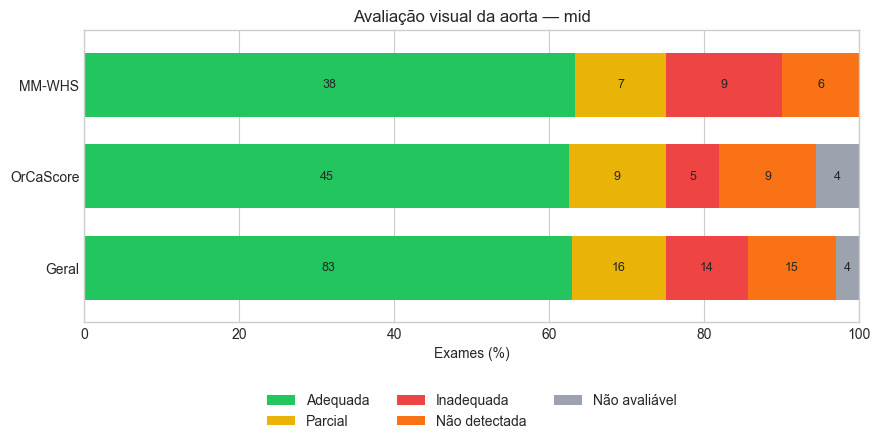

In [5]:
aorta_mid = show_aorta_visual("mid")

### High resolution

status,Exames,Adequada,Parcial,Inadequada,Não detectada,Não avaliável
dataset,,,,,,
MM-WHS,60,46 (76.7%),6 (10.0%),8 (13.3%),0 (0.0%),0 (0.0%)
OrCaScore,72,48 (66.7%),4 (5.6%),5 (6.9%),2 (2.8%),13 (18.1%)
Geral,132,94 (71.2%),10 (7.6%),13 (9.8%),2 (1.5%),13 (9.8%)


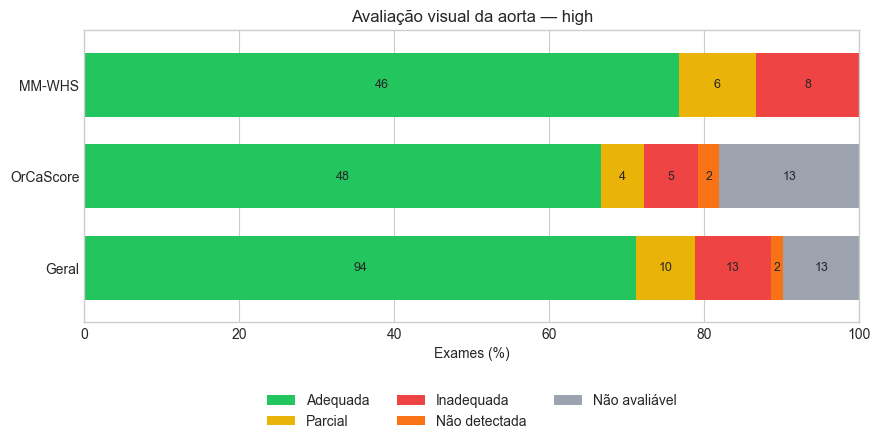

In [6]:
aorta_high = show_aorta_visual("high")

## 2. Alertas automáticos da aorta

As tabelas e gráficos mostram contagem e percentual por banco e no agregado. “Sem feedback” inclui exames sem resultado persistido ou que falharam antes do cálculo; não equivale a “Dados insuficientes”. Os alertas não substituem a avaliação visual.

### Mid resolution

status,Exames,Adequada,Suspeita de subsegmentação,Suspeita de sobresegmentação,Dados insuficientes,Sem feedback
dataset,,,,,,
MM-WHS,60,21 (35.0%),33 (55.0%),0 (0.0%),0 (0.0%),6 (10.0%)
OrCaScore,72,23 (31.9%),40 (55.6%),0 (0.0%),0 (0.0%),9 (12.5%)
Geral,132,44 (33.3%),73 (55.3%),0 (0.0%),0 (0.0%),15 (11.4%)


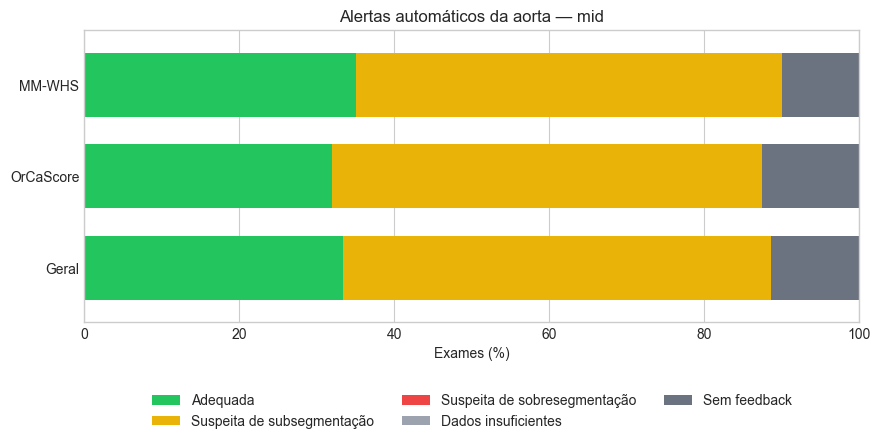

In [7]:
feedback_mid = show_aorta_feedback("mid")

### High resolution

status,Exames,Adequada,Suspeita de subsegmentação,Suspeita de sobresegmentação,Dados insuficientes,Sem feedback
dataset,,,,,,
MM-WHS,60,25 (41.7%),35 (58.3%),0 (0.0%),0 (0.0%),0 (0.0%)
OrCaScore,72,28 (38.9%),39 (54.2%),0 (0.0%),0 (0.0%),5 (6.9%)
Geral,132,53 (40.2%),74 (56.1%),0 (0.0%),0 (0.0%),5 (3.8%)


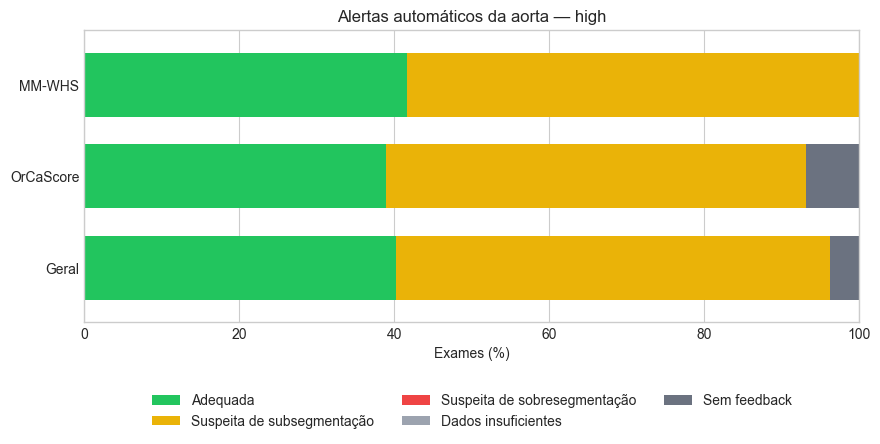

In [8]:
feedback_high = show_aorta_feedback("high")

## 3. Dice da aorta no MM-WHS (treino)

O Dice de treino compara a predição com o rótulo 820 no volume processado. O Dice de teste usa uma grade de 1 mm e aparece na seção 4, com identificação do protocolo de avaliação.

In [9]:
dice_by_case = pd.DataFrame(
    {
        resolution: load_mmwhs_train_aorta_dice(
            RUN_DIRS[resolution]["MM-WHS"] / "numeric/results_all.csv"
        )
        for resolution in RUN_DIRS
    }
)
if dice_by_case.isna().any().any():
    raise ValueError(
        "Os runs mid e high não possuem o mesmo conjunto de exames de treino"
    )
dice_by_case.index.name = "Exame"
print(f"Exames pareados com Dice: {len(dice_by_case)}")

Exames pareados com Dice: 20


### Resultado geral

,count,mean,median,std,min,max
Resolução,,,,,,
mid,20.0,0.845,0.932,0.235,0.0,0.975
high,20.0,0.858,0.938,0.235,0.0,0.980


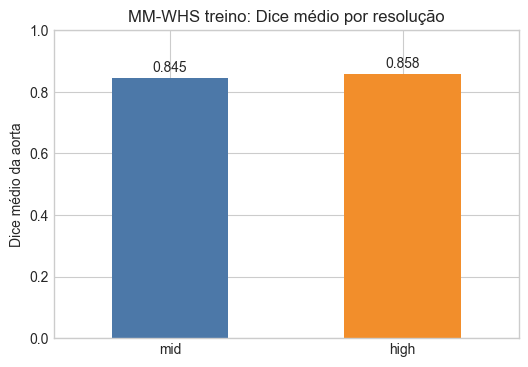

In [10]:
dice_overall = dice_by_case.agg(["count", "mean", "median", "std", "min", "max"]).T
dice_overall.index.name = "Resolução"
display(dice_overall.round(3))

ax = dice_overall["mean"].plot.bar(
    color=[RESOLUTION_COLORS[resolution] for resolution in dice_overall.index],
    figsize=(6, 4),
    ylim=(0, 1),
    rot=0,
)
ax.set(
    xlabel="",
    ylabel="Dice médio da aorta",
    title="MM-WHS treino: Dice médio por resolução",
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.3f}",
        ha="center",
    )
plt.show()

### Comparação por exame: Dice e classificações da aorta

O alerta automático e a avaliação visual aparecem lado a lado em cada resolução. Divergências mostram os limites da heurística; o Dice usa o ground truth e não é uma das entradas do alerta.

In [11]:
visual_aorta = {}
automatic_aorta = {}
for resolution in ("mid", "high"):
    paired = (
        feedback_by_resolution[resolution]
        .loc[lambda frame: frame["dataset"].eq("MM-WHS") & frame["subset"].eq("train")]
        .set_index("image_id")
    )
    missing = dice_by_case.index.difference(paired.index)
    if len(missing):
        raise ValueError(
            f"{resolution}: {len(missing)} exames com Dice sem classificação da aorta: "
            f"{missing.tolist()}"
        )
    visual_aorta[resolution] = paired["aorta_result"].reindex(dice_by_case.index)
    automatic_aorta[resolution] = paired["feedback"].reindex(dice_by_case.index)

dice_case_summary = pd.DataFrame(
    {
        "Dice mid": dice_by_case["mid"],
        "Aorta visual mid": visual_aorta["mid"],
        "Alerta automático mid": automatic_aorta["mid"],
        "Dice high": dice_by_case["high"],
        "Aorta visual high": visual_aorta["high"],
        "Alerta automático high": automatic_aorta["high"],
        "Delta Dice (high - mid)": dice_by_case["high"] - dice_by_case["mid"],
    }
)
display(dice_case_summary.round(4))

,Dice mid,Aorta visual mid,Alerta automático mid,Dice high,Aorta visual high,Alerta automático high,Delta Dice (high - mid)
Exame,,,,,,,
ct_train_1001,0.9603,Adequada,Adequada,0.8914,Adequada,Adequada,-0.0689
ct_train_1002,0.0002,Inadequada,Suspeita de subsegmentação,0.9425,Adequada,Suspeita de subsegmentação,0.9423
ct_train_1003,0.9527,Adequada,Adequada,0.9552,Adequada,Adequada,0.0025
ct_train_1004,0.9412,Adequada,Adequada,0.9803,Adequada,Adequada,0.0391
ct_train_1005,0.9263,Adequada,Suspeita de subsegmentação,0.9167,Adequada,Suspeita de subsegmentação,-0.0096
ct_train_1006,0.9163,Adequada,Suspeita de subsegmentação,0.9245,Adequada,Suspeita de subsegmentação,0.0082
ct_train_1007,0.9338,Adequada,Suspeita de subsegmentação,0.9436,Adequada,Suspeita de subsegmentação,0.0099
ct_train_1008,0.9203,Adequada,Adequada,0.9402,Adequada,Adequada,0.0199
ct_train_1009,0.4381,Inadequada,Suspeita de subsegmentação,0.8760,Adequada,Suspeita de subsegmentação,0.4379


## 4. Dice da aorta no MM-WHS (teste)

O protocolo corrigido compara somente o label 820, com referência criptografada e reamostragem para 1 mm. Resultados antigos do modo WHS são identificados como legados. As comparações exigem o mesmo protocolo em mid e high; exames sem máscara permanecem sem Dice e não entram na média.

In [12]:
test_dice_series = {
    resolution: load_mmwhs_test_aorta_dice(
        RUN_DIRS[resolution]["MM-WHS"] / "numeric/results_all.csv"
    )
    for resolution in ("mid", "high")
}
test_protocols = {
    series.attrs["aorta_evaluation_method"] for series in test_dice_series.values()
}
if len(test_protocols) != 1:
    raise ValueError(
        "Protocolos diferentes em mid/high: conclua a reavaliação antes de comparar."
    )
print("Protocolo do teste:", test_dice_series["mid"].attrs["aorta_evaluation_label"])
test_dice_by_case = pd.DataFrame(test_dice_series)
if len(test_dice_by_case) != 40:
    raise ValueError("Esperados 40 exames CT test do MM-WHS")
test_dice_by_case.index.name = "Exame"
test_dice_overall = test_dice_by_case.agg(
    ["count", "mean", "median", "std", "min", "max"]
).T
test_dice_overall.insert(0, "total de exames", len(test_dice_by_case))
test_dice_overall.index.name = "Resolução"
display(test_dice_overall.round(4))

Protocolo do teste: Aorta isolada · label 820 · 1 mm


,total de exames,count,mean,median,std,min,max
Resolução,,,,,,,
mid,40,34.0,0.7801,0.9061,0.2819,0.0,0.9733
high,40,40.0,0.7636,0.9316,0.3321,0.0,0.9748


In [13]:
test_visual_aorta = {}
for resolution in ("mid", "high"):
    paired = (
        feedback_by_resolution[resolution]
        .loc[lambda frame: frame["dataset"].eq("MM-WHS") & frame["subset"].eq("test")]
        .set_index("image_id")
    )
    if (
        paired.index.duplicated().any()
        or not test_dice_by_case.index.isin(paired.index).all()
    ):
        raise ValueError(
            f"{resolution}: avaliação visual de teste ausente ou duplicada"
        )
    test_visual_aorta[resolution] = paired["aorta_result"].reindex(
        test_dice_by_case.index
    )

test_dice_case_summary = pd.DataFrame(
    {
        "Dice mid": test_dice_by_case["mid"],
        "Aorta visual mid": test_visual_aorta["mid"],
        "Dice high": test_dice_by_case["high"],
        "Aorta visual high": test_visual_aorta["high"],
        "Delta Dice (high - mid)": test_dice_by_case["high"] - test_dice_by_case["mid"],
    }
)
display(test_dice_case_summary.round(4))

,Dice mid,Aorta visual mid,Dice high,Aorta visual high,Delta Dice (high - mid)
Exame,,,,,
ct_test_2001,0.8841,Adequada,0.8040,Adequada,-0.0801
ct_test_2002,0.9712,Adequada,0.9604,Adequada,-0.0108
ct_test_2003,0.8338,Parcial,0.7555,Parcial,-0.0784
ct_test_2004,0.9312,Adequada,0.9330,Adequada,0.0018
ct_test_2005,0.9318,Adequada,0.9482,Adequada,0.0163
ct_test_2006,0.7079,Parcial,0.9187,Adequada,0.2108
ct_test_2007,0.0071,Inadequada,0.0721,Inadequada,0.0650
ct_test_2008,0.7699,Parcial,0.0000,Inadequada,-0.7699
ct_test_2009,0.9020,Adequada,0.9346,Adequada,0.0325
